In [28]:
!pip3 install pandas numpy matplotlib seaborn scipy scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


# VEX Robotics National Tournament Qualification Ranking Analysis

## Research Question
**"How well do WP, AP, and SP actually explain qualification rankings, and is the current tiebreaker system statistically justified?"**

## Sub Question 1: Win Points (WP)
**"How strongly does Win Points (WP) alone explain qualification ranking?"**

Methods used:
- **Pearson Correlation** Measures the linear relationship between WP and Rank
- **Linear Regression** Quantifies how well WP alone predicts Rank (R²)

In [29]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [30]:
# Load data
df = pd.read_csv('VEX_Data_-_Data_Set.csv')

print(f'Total teams: {len(df)}')
print()
df.head(10)

Total teams: 44



,Team,Rank,WP,AP,SP,OPR,DPR,CCWM,W,L,T
0,1100A,1,19,80,125,66.8,-2.0,68.8,8,0,0
1,30410V,2,17,70,142,56.2,-4.2,60.4,8,0,0
2,1740X,3,16,70,114,50.9,-6.2,57.1,7,1,0
3,30597E,4,16,60,164,45.9,-9.6,55.6,8,0,0
4,3723A,5,14,60,139,23.1,8.3,14.8,6,2,0
5,30597J,6,14,50,159,51.4,9.5,41.8,6,2,0
6,14533A,7,12,55,188,44.3,9.2,35.1,6,2,0
7,6724T,8,12,40,190,33.7,26.2,7.6,6,2,0
8,30597X,9,11,50,212,39.2,12.6,26.5,5,3,0
9,3723X,10,11,40,164,21.9,25.3,-3.4,5,3,0


In [31]:
# Basic statistics
df[['Rank','WP','AP','SP','OPR','DPR','CCWM']].describe().round(2)

,Rank,WP,AP,SP,OPR,DPR,CCWM
count,44.00,44.00,44.00,44.00,44.00,44.00,44.00
mean,22.50,8.50,38.30,161.07,21.63,21.62,-0.00
std,12.85,3.90,16.74,37.15,15.84,13.74,28.15
min,1.00,0.00,5.00,72.00,-1.90,-9.60,-56.50
25%,11.75,6.00,28.75,137.25,11.12,13.65,-17.68
50%,22.50,8.00,40.00,169.00,16.65,24.65,-7.15
75%,33.25,10.25,50.00,186.50,30.05,28.80,13.88
max,44.00,19.00,80.00,232.00,66.80,56.40,68.80


## Pearson Correlation

- r = -1: perfect negative relationship
- r = 0: no relationship
- r = 1: perfect positive relationship

We expect a **negative** r since higher WP results in lower rank numbers.

In [32]:
# Pearson Correlation: WP vs Rank
r, p_value = stats.pearsonr(df['WP'], df['Rank'])

print('=== Pearson Correlation: WP vs Rank ===')
print(f'r = {r:.4f}')
print(f'p-value = {p_value:.6f}')
print()

if p_value < 0.05:
    print('Result: Statistically SIGNIFICANT (p < 0.05)')
else:
    print('Result: NOT statistically significant (p > 0.05)')

print()
print('Interpretation:')
if abs(r) >= 0.7:
    print(f'Strong correlation (r = {r:.4f}): WP is a strong predictor of ranking.')
elif abs(r) >= 0.4:
    print(f'Moderate correlation (r = {r:.4f}): WP partially explains ranking.')
else:
    print(f'Weak correlation (r = {r:.4f}): WP alone poorly explains ranking.')

=== Pearson Correlation: WP vs Rank ===
r = -0.9176
p-value = 0.000000

Result: Statistically SIGNIFICANT (p < 0.05)

Interpretation:
Strong correlation (r = -0.9176): WP is a strong predictor of ranking.


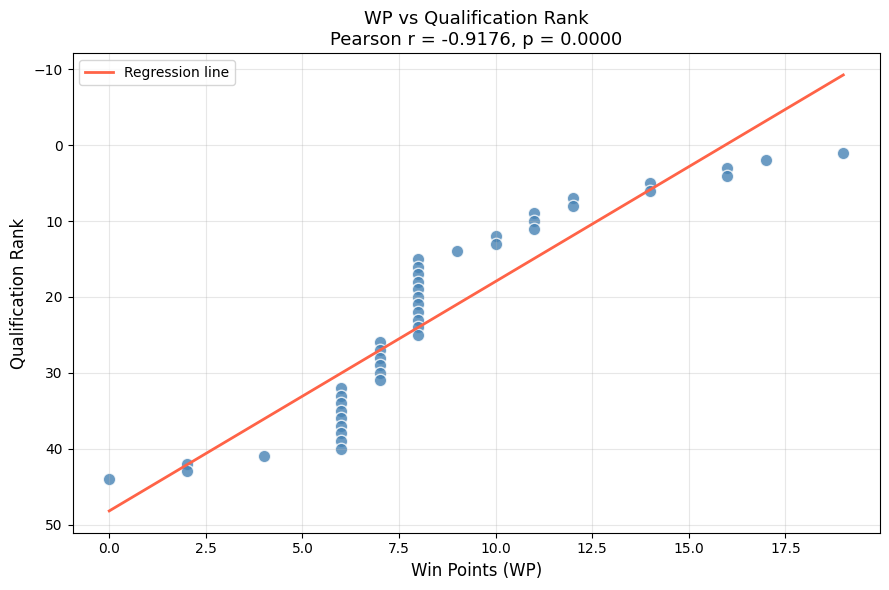

Figure saved.


In [33]:
# Visualization: WP vs Rank scatter plot
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['WP'], df['Rank'], color='steelblue', edgecolors='white', s=80, alpha=0.8)

# Add regression line
m, b = np.polyfit(df['WP'], df['Rank'], 1)
x_line = np.linspace(df['WP'].min(), df['WP'].max(), 100)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, label='Regression line')

ax.set_xlabel('Win Points (WP)', fontsize=12)
ax.set_ylabel('Qualification Rank', fontsize=12)
ax.set_title(f'WP vs Qualification Rank\nPearson r = {r:.4f}, p = {p_value:.4f}', fontsize=13)
ax.invert_yaxis()  # Rank 1 at top
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sub1_pearson_wp_rank.png', dpi=150)
plt.show()
print('Figure saved.')

## Linear Regression 

Linear Regression quantifies how much of the variance in Rank is explained by WP alone.

**R²** (coefficient of determination):
- R² = 1.0: WP perfectly predicts Rank
- R² = 0.0: WP explains nothing about Rank

If R² is low, it means WP alone is insufficient, which justifies the need for tiebreakers (AP, SP).

In [34]:
# Linear Regression: WP → Rank
X = df[['WP']]
y = df['Rank']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print('=== Linear Regression: WP → Rank ===')
print(f'Coefficient (slope): {model.coef_[0]:.4f}')
print(f'Intercept:           {model.intercept_:.4f}')
print(f'R²:                  {r2:.4f}')
print()
print(f'Interpretation: WP alone explains {r2*100:.1f}% of the variance in qualification ranking.')
print()

if r2 >= 0.7:
    print('Strong predictive power, WP is a dominant factor in ranking.')
elif r2 >= 0.4:
    print('Moderate predictive power, WP partially determines ranking, but tiebreakers matter.')
else:
    print('Weak predictive power, WP alone is insufficient. Tiebreakers are critical.')

=== Linear Regression: WP → Rank ===
Coefficient (slope): -3.0245
Intercept:           48.2083
R²:                  0.8419

Interpretation: WP alone explains 84.2% of the variance in qualification ranking.

Strong predictive power, WP is a dominant factor in ranking.


/var/folders/zp/w_vsmpq54wzf0vrcktvxwzb40000gn/T/ipykernel_99105/23205234.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, labels=['Top (1-15)', 'Mid (16-30)', 'Bottom (31-44)'], patch_artist=True,


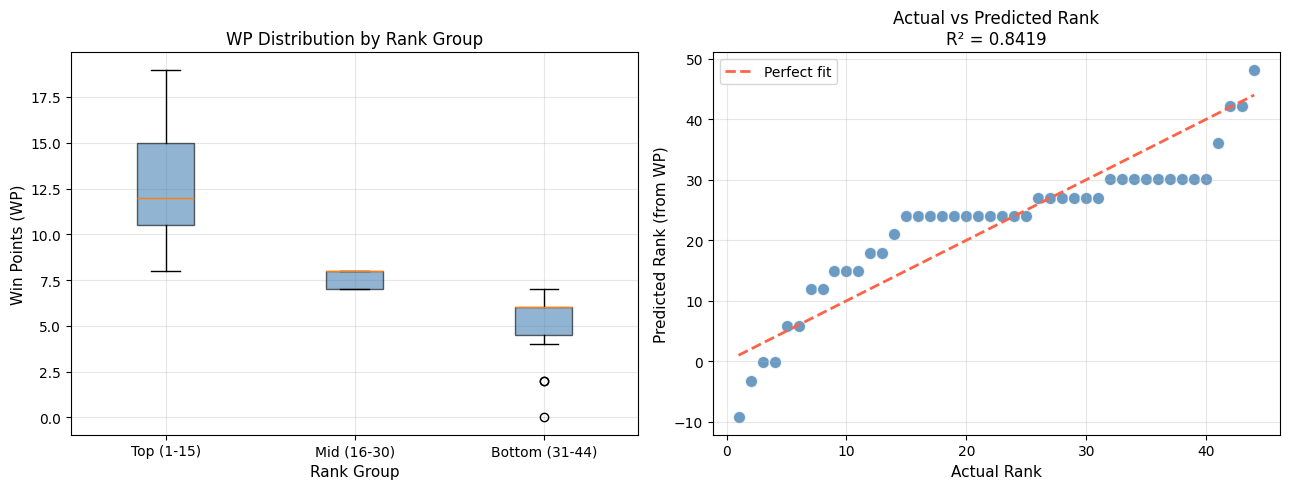

Figure saved.


In [35]:
# Visualization: WP distribution by rank groups
df['Rank_Group'] = pd.cut(df['Rank'], bins=[0, 15, 30, 44],
                           labels=['Top (1-15)', 'Mid (16-30)', 'Bottom (31-44)'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
groups = [df[df['Rank_Group'] == g]['WP'].values for g in ['Top (1-15)', 'Mid (16-30)', 'Bottom (31-44)']]
axes[0].boxplot(groups, labels=['Top (1-15)', 'Mid (16-30)', 'Bottom (31-44)'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_xlabel('Rank Group', fontsize=11)
axes[0].set_ylabel('Win Points (WP)', fontsize=11)
axes[0].set_title('WP Distribution by Rank Group', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Actual vs Predicted
axes[1].scatter(y, y_pred, color='steelblue', edgecolors='white', s=80, alpha=0.8)
axes[1].plot([1, 44], [1, 44], color='tomato', linewidth=2, linestyle='--', label='Perfect fit')
axes[1].set_xlabel('Actual Rank', fontsize=11)
axes[1].set_ylabel('Predicted Rank (from WP)', fontsize=11)
axes[1].set_title(f'Actual vs Predicted Rank\nR² = {r2:.4f}', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sub1_regression_wp_rank.png', dpi=150)
plt.show()
print('Figure saved.')

## Sub Question 1: Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Pearson r | -0.9176 | Strength of WP-Rank relationship |
| p-value | 0.000000 | Statistical significance |
| R² | 0.8419 | % of ranking variance explained by WP |

**Key Finding:**
WP is strongly correlated with qualification ranking. However, because multiple teams share the same WP value, WP alone cannot fully determine rankings, providing statistical justification for tiebreaker metrics.